In [13]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 0. Data Loading

In [18]:
curr_path = os.getcwd()
csv_path = curr_path.replace("data_analysis", "datasets/NF-CSE-CIC-IDS2018-v3/NF-CSE-CIC-IDS2018-v3.csv")
timestamp_cols = {"FLOW_START_MILLISECONDS", "FLOW_END_MILLISECONDS"}
chunks = []
for chunk in pd.read_csv(csv_path, chunksize=500_000):
    for col in chunk.select_dtypes(include=["float64"]).columns:
        chunk[col] = chunk[col].astype(np.float32)
    for col in chunk.select_dtypes(include=["int64"]).columns:
        if col in timestamp_cols:
            continue
        elif col == "Label":
            chunk[col] = chunk[col].astype(np.int8)
        else:
            chunk[col] = chunk[col].astype(np.int32)
    chunks.append(chunk)
df = pd.concat(chunks, ignore_index=True)
del chunks

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20115529 entries, 0 to 20115528
Data columns (total 55 columns):
 #   Column                       Dtype
---  ------                       -----
 0   FLOW_START_MILLISECONDS      int64
 1   FLOW_END_MILLISECONDS        int64
 2   IPV4_SRC_ADDR                str  
 3   L4_SRC_PORT                  int32
 4   IPV4_DST_ADDR                str  
 5   L4_DST_PORT                  int32
 6   PROTOCOL                     int32
 7   L7_PROTO                     int32
 8   IN_BYTES                     int32
 9   IN_PKTS                      int32
 10  OUT_BYTES                    int32
 11  OUT_PKTS                     int32
 12  TCP_FLAGS                    int32
 13  CLIENT_TCP_FLAGS             int32
 14  SERVER_TCP_FLAGS             int32
 15  FLOW_DURATION_MILLISECONDS   int32
 16  DURATION_IN                  int32
 17  DURATION_OUT                 int32
 18  MIN_TTL                      int32
 19  MAX_TTL                      int32
 20  LONGEST_FLO

# 1. Data Overview

In [ ]:
pd.set_option("display.max_columns", None)
df.head()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1518611287705,1518611287705,172.31.0.2,53,172.31.66.58,63593,17,5,156,1,0,0,0,0,0,1,0,0,0,0,156,156,0,156,0,1,0,0,0,0,1248000,0,0,1,0,0,0,0,0,0,0,45856,1,60,0,0,0,0,0,0,0,0,0,0,Benign
1,1518611287743,1518611290747,172.31.66.58,56163,239.255.255.250,1900,17,12,805,5,0,0,0,0,0,3003,3003,0,1,1,161,161,0,161,0,0,0,0,0,0,2143,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,2793,750,1182,0,0,0,0,0,Benign
2,1518611288143,1518611300202,172.31.66.46,62388,239.255.255.250,1900,17,12,1288,8,0,0,0,0,0,12058,12058,0,1,1,161,161,0,161,0,0,0,0,0,0,854,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,3016,1722,1436,0,0,0,0,0,Benign
3,1518611288165,1518611336194,0.0.0.0,546,0.0.0.0,547,17,103,393,3,0,0,0,0,0,48029,48029,0,1,1,131,131,0,131,0,0,0,0,0,0,65,0,0,3,0,0,0,0,0,0,0,0,0,0,0,16014,32014,24014,8000,0,0,0,0,0,Benign
4,1518611288175,1518611288176,172.31.66.46,49187,169.254.169.254,80,6,7,373,5,700,5,27,27,27,1,0,0,128,128,528,40,40,528,700,373,0,0,0,0,1492000,2800000,8,1,0,1,0,8192,17922,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign


In [20]:
df.tail()

,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
20115524,1519334572956,1519334662435,52.14.77.172,1024,172.31.69.28,500,17,79,3168,6,0,0,0,0,0,89479,89479,0,62,62,528,528,0,528,0,0,0,0,0,0,283,0,0,0,0,6,0,0,0,0,0,0,0,0,0,4000,41989,17895,13724,0,0,0,0,1,Brute_Force_-XSS
20115525,1519334689509,1519334778989,13.58.42.57,1028,172.31.69.28,500,17,79,3168,6,0,0,0,0,0,89479,89479,0,62,62,528,528,0,528,0,0,0,0,0,0,283,0,0,0,0,6,0,0,0,0,0,0,0,0,0,4000,41990,17895,13725,0,0,0,0,1,Brute_Force_-XSS
20115526,1519334738019,1519334827498,52.14.77.172,1024,172.31.69.28,500,17,79,3168,6,0,0,0,0,0,89479,89479,0,62,62,528,528,0,528,0,0,0,0,0,0,283,0,0,0,0,6,0,0,0,0,0,0,0,0,0,4000,41990,17895,13725,0,0,0,0,1,Brute_Force_-XSS
20115527,1519334854572,1519334944052,13.58.42.57,1028,172.31.69.28,500,17,79,3168,6,0,0,0,0,0,89479,89479,0,62,62,528,528,0,528,0,0,0,0,0,0,283,0,0,0,0,6,0,0,0,0,0,0,0,0,0,4000,41990,17895,13725,0,0,0,0,1,Brute_Force_-XSS
20115528,1519334903081,1519334992561,52.14.77.172,1024,172.31.69.28,500,17,79,3168,6,0,0,0,0,0,89479,89479,0,62,62,528,528,0,528,0,0,0,0,0,0,283,0,0,0,0,6,0,0,0,0,0,0,0,0,0,4000,41990,17895,13725,0,0,0,0,1,Brute_Force_-XSS


In [6]:
df.shape

(20115529, 55)

This are the features on the dataset and their description according to the dataset documentation:

| Feature | Description |
| --- | --- |
| IPV4 SRC ADDR | IPv4 source address |
| IPV4 DST ADDR | IPv4 destination address |
| L4 SRC PORT | IPv4 source port number |
| L4 DST PORT | IPv4 destination port number |
| PROTOCOL | IP protocol identifier byte |
| L7 PROTO | Application protocol (numeric) |
| IN BYTES | Incoming number of bytes |
| OUT BYTES | Outgoing number of bytes |
| IN PKTS | Incoming number of packets |
| OUT PKTS | Outgoing number of packets |
| FLOW DURATION MILLISECONDS | Flow duration in milliseconds |
| TCP FLAGS | Cumulative of all TCP flags |
| CLIENT TCP FLAGS | Cumulative of all client TCP flags |
| SERVER TCP FLAGS | Cumulative of all server TCP flags |
| DURATION IN | Client to Server stream duration (msec) |
| DURATION OUT | Client to Server stream duration (msec) |
| MIN TTL | Min flow TTL |
| MAX TTL | Max flow TTL |
| LONGEST FLOW PKT | Longest packet (bytes) of the flow |
| SHORTEST FLOW PKT | Shortest packet (bytes) of the flow |
| MIN IP PKT LEN | Len of the smallest flow IP packet observed |
| MAX IP PKT LEN | Len of the largest flow IP packet observed |
| SRC TO DST SECOND BYTES | Src to dst Bytes/sec |
| DST TO SRC SECOND BYTES | Dst to src Bytes/sec |
| RETRANSMITTED IN BYTES | Number of retransmitted TCP flow bytes (src->dst) |
| RETRANSMITTED IN PKTS | Number of retransmitted TCP flow packets (src->dst) |
| RETRANSMITTED OUT BYTES | Number of retransmitted TCP flow bytes (dst->src) |
| RETRANSMITTED OUT PKTS | Number of retransmitted TCP flow packets (dst->src) |
| SRC TO DST AVG THROUGHPUT | Src to dst average thpt (bps) |
| DST TO SRC AVG THROUGHPUT | Dst to src average thpt (bps) |
| NUM PKTS UP TO 128 BYTES | Packets whose IP size <= 128 |
| NUM PKTS 128 TO 256 BYTES | Packets whose IP size > 128 and <= 256 |
| NUM PKTS 256 TO 512 BYTES | Packets whose IP size > 256 and <= 512 |
| NUM PKTS 512 TO 1024 BYTES | Packets whose IP size > 512 and <= 1024 |
| NUM PKTS 1024 TO 1514 BYTES | Packets whose IP size > 1024 and <= 1514 |
| TCP WIN MAX IN | Max TCP Window (src->dst) |
| TCP WIN MAX OUT | Max TCP Window (dst->src) |
| ICMP TYPE | ICMP Type * 256 + ICMP code |
| ICMP IPV4 TYPE | ICMP Type |
| DNS QUERY ID | DNS query transaction Id |
| DNS QUERY TYPE | DNS query type (e.g., 1=A, 2=NS..) |
| DNS TTL ANSWER | TTL of the first A record (if any) |
| FTP COMMAND RET CODE | FTP client command return code |
| FLOW START MILLISECONDS | Flow start timestamp in milliseconds |
| FLOW END MILLISECONDS | Flow end timestamp in milliseconds |
| SRC TO DST IAT MIN | Minimum IAT (src->dst) |
| SRC TO DST IAT MAX | Maximum IAT (src->dst) |
| SRC TO DST IAT AVG | Average IAT (src->dst) |
| SRC TO DST IAT STDDEV | Standard deviation of IAT (src->dst) |
| DST TO SRC IAT MIN | Minimum IAT (dst->src) |
| DST TO SRC IAT MAX | Maximum IAT (dst->src) |
| DST TO SRC IAT AVG | Average IAT (dst->src) |
| DST TO SRC IAT STDDEV | Standard deviation of IAT (dst->src) |

# 2. Data Quality

In [7]:
df.isnull().sum()

FLOW_START_MILLISECONDS        0
FLOW_END_MILLISECONDS          0
IPV4_SRC_ADDR                  0
L4_SRC_PORT                    0
IPV4_DST_ADDR                  0
L4_DST_PORT                    0
PROTOCOL                       0
L7_PROTO                       0
IN_BYTES                       0
IN_PKTS                        0
OUT_BYTES                      0
OUT_PKTS                       0
TCP_FLAGS                      0
CLIENT_TCP_FLAGS               0
SERVER_TCP_FLAGS               0
FLOW_DURATION_MILLISECONDS     0
DURATION_IN                    0
DURATION_OUT                   0
MIN_TTL                        0
MAX_TTL                        0
LONGEST_FLOW_PKT               0
SHORTEST_FLOW_PKT              0
MIN_IP_PKT_LEN                 0
MAX_IP_PKT_LEN                 0
SRC_TO_DST_SECOND_BYTES        0
DST_TO_SRC_SECOND_BYTES        0
RETRANSMITTED_IN_BYTES         0
RETRANSMITTED_IN_PKTS          0
RETRANSMITTED_OUT_BYTES        0
RETRANSMITTED_OUT_PKTS         0
SRC_TO_DST

In [25]:
num_duplicates = df.duplicated().sum() 
total_involved = df.duplicated(keep=False).sum()
num_unique_pairs = num_duplicates

print(f"Total rows in dataset: {len(df):,}")
print(f"Rows marked as duplicates: {num_duplicates:,}")
print(f"Total rows involved in duplication: {total_involved:,}")

Total rows in dataset: 20,115,529
Rows marked as duplicates: 628,474
Total rows involved in duplication: 1,256,674


In [26]:
# Remove duplicates, keeping first occurrence
df_no_dups_first = df.drop_duplicates(keep='first')
print(f"After removing duplicates (keep first): {len(df_no_dups_first):,} rows")
print(f"Rows removed: {len(df) - len(df_no_dups_first):,}")

After removing duplicates (keep first): 19,487,055 rows
Rows removed: 628,474


In [9]:
df['Attack'].unique()

<StringArray>
[                  'Benign',           'FTP-BruteForce',
           'SSH-Bruteforce',    'DoS_attacks-GoldenEye',
    'DoS_attacks-Slowloris', 'DoS_attacks-SlowHTTPTest',
         'DoS_attacks-Hulk',   'DDoS_attacks-LOIC-HTTP',
     'DDOS_attack-LOIC-UDP',         'DDOS_attack-HOIC',
         'Brute_Force_-Web',         'Brute_Force_-XSS',
            'SQL_Injection',            'Infilteration',
                      'Bot']
Length: 15, dtype: str

In [27]:
v = df['Attack'].value_counts()

# Add side by side vs df_no_dups_first['Attack'].value_counts()
v2 = df_no_dups_first['Attack'].value_counts()

side_by_side = pd.DataFrame({'With Duplicates': v, 'Without Duplicates': v2})
print(side_by_side)

                          With Duplicates  Without Duplicates
Attack                                                       
Benign                           17514626            17392754
Bot                                207703              111460
Brute_Force_-Web                     1618                1618
Brute_Force_-XSS                      480                 460
DDOS_attack-HOIC                  1032311             1032311
DDOS_attack-LOIC-UDP                 3450                1725
DDoS_attacks-LOIC-HTTP             288589              288589
DoS_attacks-GoldenEye               61300               30650
DoS_attacks-Hulk                   100076              100076
DoS_attacks-SlowHTTPTest           105550              105550
DoS_attacks-Slowloris               36040               18020
FTP-BruteForce                     386720              193360
Infilteration                      188152              115805
SQL_Injection                         440                 440
SSH-Brut

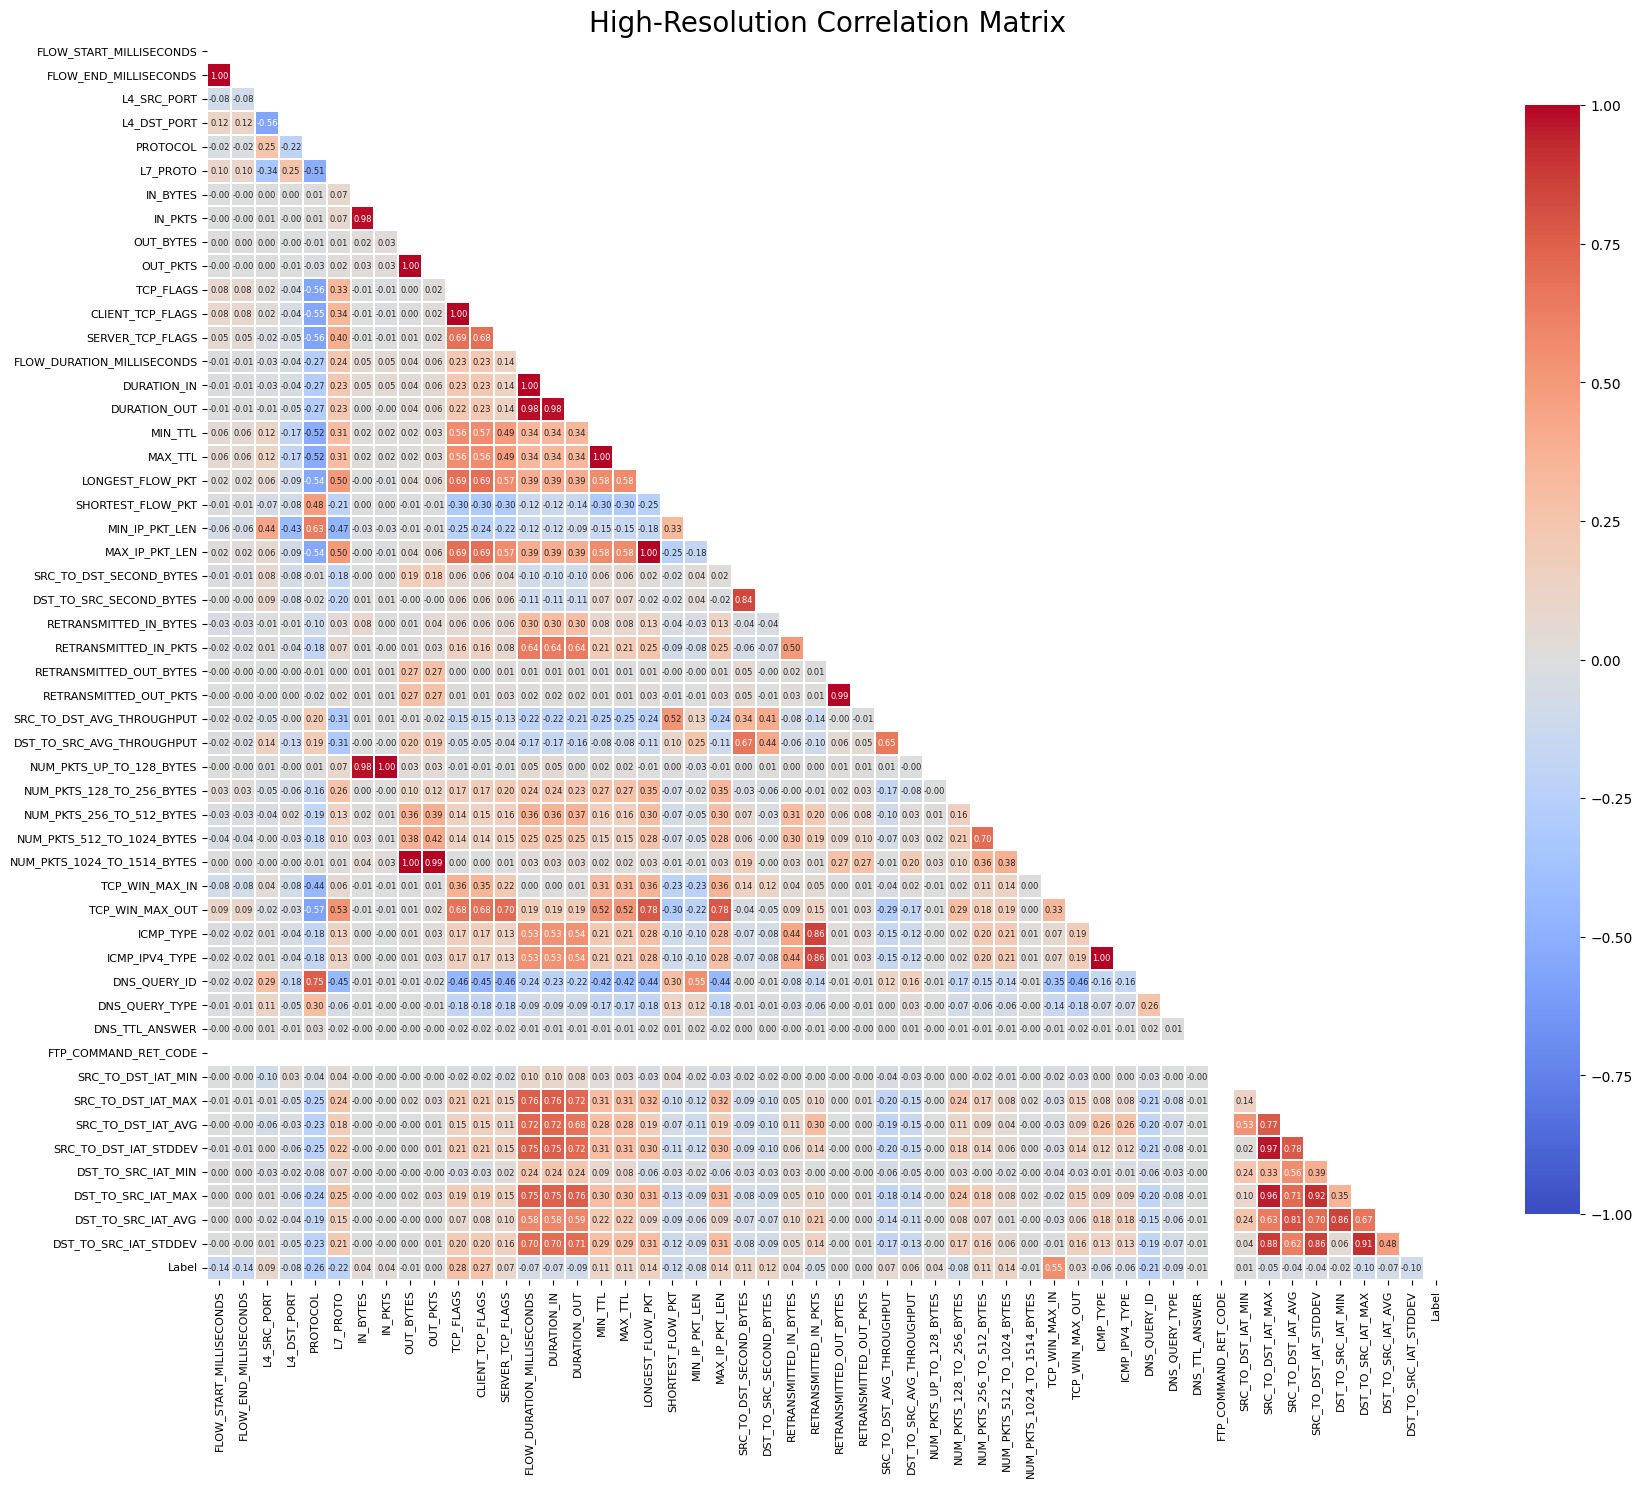

In [17]:
plt.figure(figsize=(20, 18), dpi=100) 
corr = df.select_dtypes(include=['number']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr, 
    mask=mask, 
    annot=True,            # Set to False if the numbers still overlap too much
    fmt=".2f",             # Two decimal places
    cmap='coolwarm',       # Diverging palette (Red = Pos, Blue = Neg)
    vmin=-1, vmax=1,       # Standardize the scale
    center=0,
    square=True,           # Ensures cells are perfect squares
    linewidths=.1,         # Tiny lines to separate the 57 features
    cbar_kws={"shrink": .8}, # Adjust colorbar size
    annot_kws={"size": 6}  # Tiny font for the 57x57 grid
)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.title('High-Resolution Correlation Matrix', fontsize=20)
plt.show()